# 4. Implementing Matrix Factorization

## (b) Data Compression  


### **Objective**  
Explore low-rank **matrix factorization for compression** on a patch of size 50×50 pixels.  

Cases to analyze:  
1. A patch with mainly **a single color**.  
2. A patch with **2–3 different colors**.  
3. A patch with **5 or more different colors**.  

Tasks:  
- Use Gradient Descent for matrix factorization.  
- Vary rank values as: `r = [5, 10, 25, 50]`.  
- For each patch:  
  - Reconstruct using low-rank factors.  
  - Replace reconstructed patch back into the original image (keeping other pixels unchanged).  
  - Plot reconstructed vs original patches.  
- Write **observations** on how reconstruction quality changes with:  
  - Different ranks,  
  - Different patch complexity (colors).  


Importing Libraries


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torchvision
import matplotlib.patches as mpatches

Setting up Device

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():  # For Mac GPUs
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Working on device:", device)

Working on device: cpu


Defining Random Seed

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Colored image shape (C,H,W): torch.Size([3, 1365, 2048])
Min pixel value: 0.0
Max pixel value: 1.0


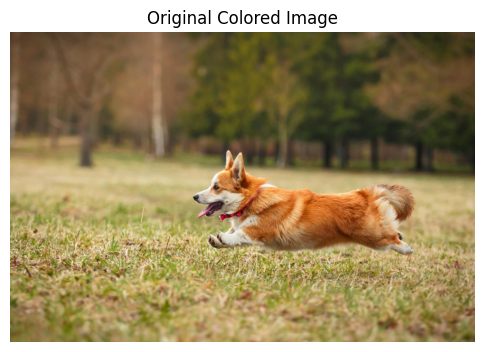

In [4]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0


color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\dog.jpg')  # shape: [C, H, W]
color_img = normalize_image(color_img)
print("Colored image shape (C,H,W):", color_img.shape)
print("Min pixel value:", color_img.min().item())
print("Max pixel value:", color_img.max().item())

# Display colored image
plt.figure(figsize=(6,6))
plt.imshow(color_img.permute(1,2,0))  # convert [C,H,W] -> [H,W,C] for matplotlib
plt.title("Original Colored Image")
plt.axis('off')
plt.show()

Cropping The Image

torch.Size([3, 300, 300])


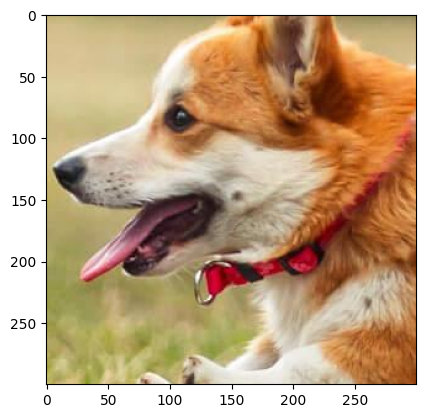

In [20]:
crop = torchvision.transforms.functional.crop(color_img, 600, 800, 300, 300)
color_img = crop
print(color_img.shape)
plt.imshow(color_img.permute(1, 2, 0))

In [21]:
def show_patch(image, top_left, N=50):
    fig, ax = plt.subplots(1,1,figsize=(6,6))
    ax.imshow(image.permute(1,2,0).cpu())
    rect = mpatches.Rectangle((top_left[1], top_left[0]), N, N, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.set_title(f"Selected Patch at {top_left}")
    #ax.axis('off')
    plt.show()

In [22]:
def low_rank_gd(patch, rank, lr=0.01, num_iters=10000):
    C, H, W = patch.shape
    patch_reconstructed = torch.zeros_like(patch)

    for c in range(C):
        X = patch[c]  # [H,W]

        # Initialize U and V
        U = torch.randn(H, rank, device=device, requires_grad=True)
        V = torch.randn(W, rank, device=device, requires_grad=True)

        optimizer = optim.Adam([U, V], lr=lr)

        for it in range(num_iters):
            optimizer.zero_grad()
            X_hat = U @ V.T
            loss = ((X - X_hat) ** 2).mean()
            loss.backward()
            optimizer.step()

            # Print loss every 500 iterations and at the last iteration
            if it % 500 == 0 or it == num_iters - 1:
                print(f"Channel {c+1}, GD Iteration {it:5d}, Loss={loss.item():.6f}")

        patch_reconstructed[c] = U @ V.T

    return patch_reconstructed


In [9]:
def replace_patch(original_img, reconstructed_patch, top_left):
    img_copy = original_img.clone()
    x, y = top_left
    _, N, _ = reconstructed_patch.shape
    img_copy[:, x:x+N, y:y+N] = reconstructed_patch
    return img_copy

In [26]:
def compute_metrics(X_true, X_pred):
    """Compute RMSE and PSNR over a patch or image"""
    mse = ((X_true - X_pred).pow(2)).mean()
    rmse = torch.sqrt(mse).item()
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse)).item()
    return rmse, psnr

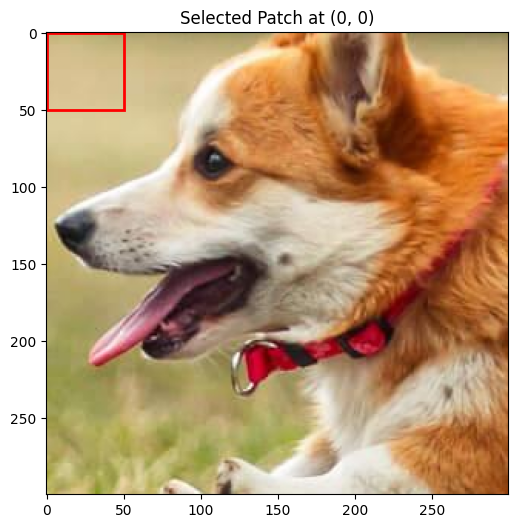


--- Patch: Single color ---
Channel 1, GD Iteration     0, Loss=6.573289
Channel 1, GD Iteration   500, Loss=0.001922
Channel 1, GD Iteration   999, Loss=0.000096
Channel 2, GD Iteration     0, Loss=4.793328
Channel 2, GD Iteration   500, Loss=0.001192
Channel 2, GD Iteration   999, Loss=0.000124
Channel 3, GD Iteration     0, Loss=6.109491
Channel 3, GD Iteration   500, Loss=0.000822
Channel 3, GD Iteration   999, Loss=0.000055
Rank 5: RMSE=0.009582, PSNR=40.37 dB
Channel 1, GD Iteration     0, Loss=10.173906
Channel 1, GD Iteration   500, Loss=0.000114
Channel 1, GD Iteration   999, Loss=0.000077
Channel 2, GD Iteration     0, Loss=10.148066
Channel 2, GD Iteration   500, Loss=0.000145
Channel 2, GD Iteration   999, Loss=0.000047
Channel 3, GD Iteration     0, Loss=9.544217
Channel 3, GD Iteration   500, Loss=0.001174
Channel 3, GD Iteration   999, Loss=0.000088
Rank 10: RMSE=0.008396, PSNR=41.52 dB
Channel 1, GD Iteration     0, Loss=24.524479
Channel 1, GD Iteration   500, Loss=0.

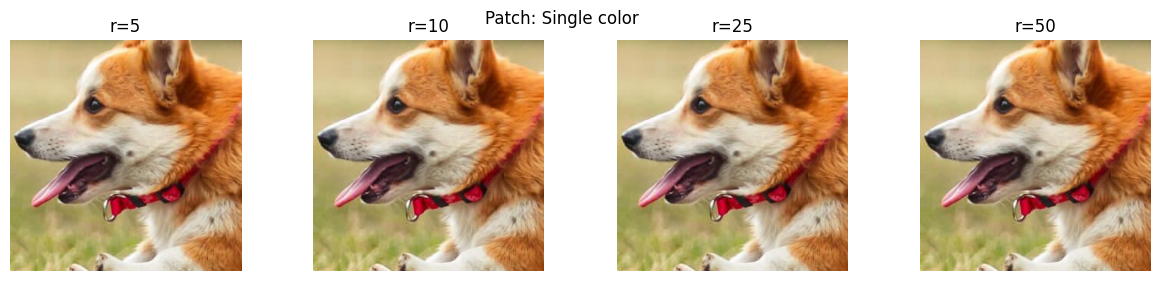

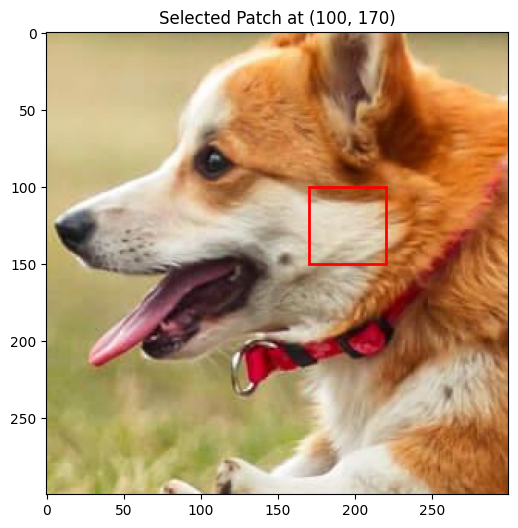


--- Patch: 2-3 colors ---
Channel 1, GD Iteration     0, Loss=5.757423
Channel 1, GD Iteration   500, Loss=0.002018
Channel 1, GD Iteration   999, Loss=0.001336
Channel 2, GD Iteration     0, Loss=4.854360
Channel 2, GD Iteration   500, Loss=0.003146
Channel 2, GD Iteration   999, Loss=0.002283
Channel 3, GD Iteration     0, Loss=5.952947
Channel 3, GD Iteration   500, Loss=0.004944
Channel 3, GD Iteration   999, Loss=0.003187
Rank 5: RMSE=0.047626, PSNR=26.44 dB
Channel 1, GD Iteration     0, Loss=11.148798
Channel 1, GD Iteration   500, Loss=0.001556
Channel 1, GD Iteration   999, Loss=0.001256
Channel 2, GD Iteration     0, Loss=9.356153
Channel 2, GD Iteration   500, Loss=0.002218
Channel 2, GD Iteration   999, Loss=0.002087
Channel 3, GD Iteration     0, Loss=12.560169
Channel 3, GD Iteration   500, Loss=0.004071
Channel 3, GD Iteration   999, Loss=0.002927
Rank 10: RMSE=0.045714, PSNR=26.80 dB
Channel 1, GD Iteration     0, Loss=25.031704
Channel 1, GD Iteration   500, Loss=0.00

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04134181..1.0].


Channel 3, GD Iteration   999, Loss=0.001774
Rank 25: RMSE=0.036568, PSNR=28.74 dB
Channel 1, GD Iteration     0, Loss=50.769875
Channel 1, GD Iteration   500, Loss=0.000878
Channel 1, GD Iteration   999, Loss=0.000336
Channel 2, GD Iteration     0, Loss=52.883125
Channel 2, GD Iteration   500, Loss=0.001010
Channel 2, GD Iteration   999, Loss=0.000618
Channel 3, GD Iteration     0, Loss=46.217800
Channel 3, GD Iteration   500, Loss=0.001406


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0025848928..1.0].


Channel 3, GD Iteration   999, Loss=0.000437
Rank 50: RMSE=0.021525, PSNR=33.34 dB


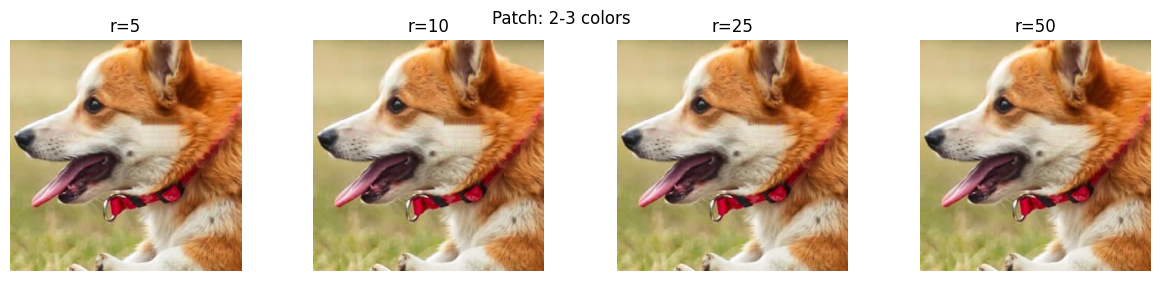

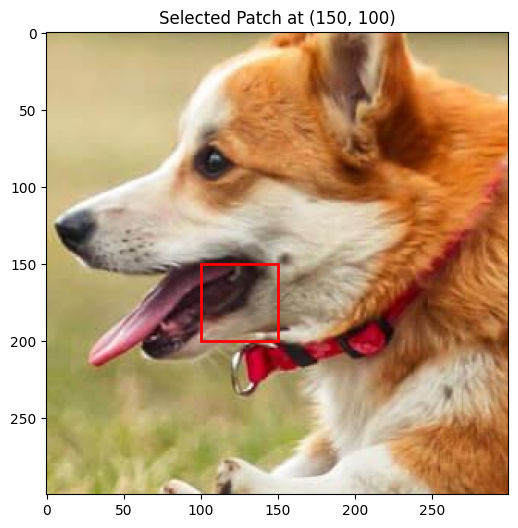


--- Patch: >=5 colors ---
Channel 1, GD Iteration     0, Loss=6.429556
Channel 1, GD Iteration   500, Loss=0.013187
Channel 1, GD Iteration   999, Loss=0.011650
Channel 2, GD Iteration     0, Loss=5.283049
Channel 2, GD Iteration   500, Loss=0.013010
Channel 2, GD Iteration   999, Loss=0.007590
Channel 3, GD Iteration     0, Loss=5.555030
Channel 3, GD Iteration   500, Loss=0.010993


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.015429791..1.0].


Channel 3, GD Iteration   999, Loss=0.007618
Rank 5: RMSE=0.094596, PSNR=20.48 dB
Channel 1, GD Iteration     0, Loss=9.757874
Channel 1, GD Iteration   500, Loss=0.008685
Channel 1, GD Iteration   999, Loss=0.004798
Channel 2, GD Iteration     0, Loss=10.884580
Channel 2, GD Iteration   500, Loss=0.011539
Channel 2, GD Iteration   999, Loss=0.003847
Channel 3, GD Iteration     0, Loss=11.077630
Channel 3, GD Iteration   500, Loss=0.011387
Channel 3, GD Iteration   999, Loss=0.006800
Rank 10: RMSE=0.071721, PSNR=22.89 dB
Channel 1, GD Iteration     0, Loss=22.109598
Channel 1, GD Iteration   500, Loss=0.006422
Channel 1, GD Iteration   999, Loss=0.002715
Channel 2, GD Iteration     0, Loss=23.285398
Channel 2, GD Iteration   500, Loss=0.006036
Channel 2, GD Iteration   999, Loss=0.002358
Channel 3, GD Iteration     0, Loss=25.150606


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02411394..1.0].


Channel 3, GD Iteration   500, Loss=0.006355
Channel 3, GD Iteration   999, Loss=0.002229
Rank 25: RMSE=0.049308, PSNR=26.14 dB
Channel 1, GD Iteration     0, Loss=47.718121
Channel 1, GD Iteration   500, Loss=0.002504
Channel 1, GD Iteration   999, Loss=0.000991
Channel 2, GD Iteration     0, Loss=48.768738
Channel 2, GD Iteration   500, Loss=0.002499
Channel 2, GD Iteration   999, Loss=0.001132
Channel 3, GD Iteration     0, Loss=48.464405
Channel 3, GD Iteration   500, Loss=0.002546
Channel 3, GD Iteration   999, Loss=0.000649
Rank 50: RMSE=0.030381, PSNR=30.35 dB


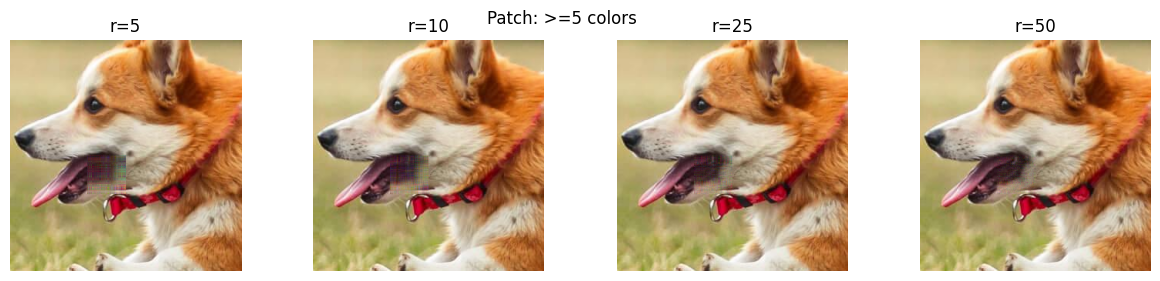

In [29]:
N = 50
patch_coords = [(0,0), (100,170), (150,100)]
patch_names = ['Single color', '2-3 colors', '>=5 colors']


ranks = [5, 10, 25, 50]

for idx, top_left in enumerate(patch_coords):
    x, y = top_left
    patch = color_img[:, x:x+N, y:y+N]

    # Show selected patch
    show_patch(color_img, top_left, N)

    print(f"\n--- Patch: {patch_names[idx]} ---")
    plt.figure(figsize=(15,3))

    for i, r in enumerate(ranks):
        reconstructed = low_rank_gd(patch, rank=r, lr=0.01, num_iters=1000)
        img_with_patch = replace_patch(color_img, reconstructed, top_left)

        # Compute metrics
        rmse, psnr = compute_metrics(patch, reconstructed)
        print(f"Rank {r}: RMSE={rmse:.6f}, PSNR={psnr:.2f} dB")

        # Plot reconstructed image
        plt.subplot(1, len(ranks), i+1)
        plt.imshow(img_with_patch.detach().cpu().permute(1,2,0))
        plt.title(f"r={r}")
        plt.axis('off')

    plt.suptitle(f"Patch: {patch_names[idx]}")
    plt.show()